In [138]:
import sys
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import time
from wave_cluster import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data

In [2]:
# US state level infections, population, geography, and government response data
infections = pd.read_csv("../data/state/infections.csv", index_col = 0)
population = pd.read_csv("../data/state/population.csv", index_col = 0)
geography = pd.read_csv("../data/state/geography.csv", index_col = 0)
gov_response = pd.read_csv("../data/state/gov_response.csv", index_col = 0)

# Normalization of each locations time-series to be cases per 100,000 persons
norm = infections.apply(lambda x: x/(population.loc[x.name].iloc[0]))
infections = norm * 100000 # cases per 100,000

# Windowed average smoothing of each time-series 
# Using average of 7 days in front and behind burrent time-stamp, 
# and repeating 3 times for a smoother result. 
front = 7
back = 7
smoothed = window_average_2d(infections.to_numpy(), front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)
smoothed = window_average_2d(smoothed, front = front, back = back)

# remove any negative entries (reporting errors still present after smoothing)
smoothed[smoothed < 0] = 0

# fix the indexes
smoothed_index = pd.to_datetime(infections.index[front*3:-back*3])
infections = pd.DataFrame(smoothed, index = smoothed_index, columns = infections.columns)
gov_response = gov_response.iloc[front*3:-back*3]
gov_response.index = pd.to_datetime(gov_response.index)

dataset = infections.to_numpy()

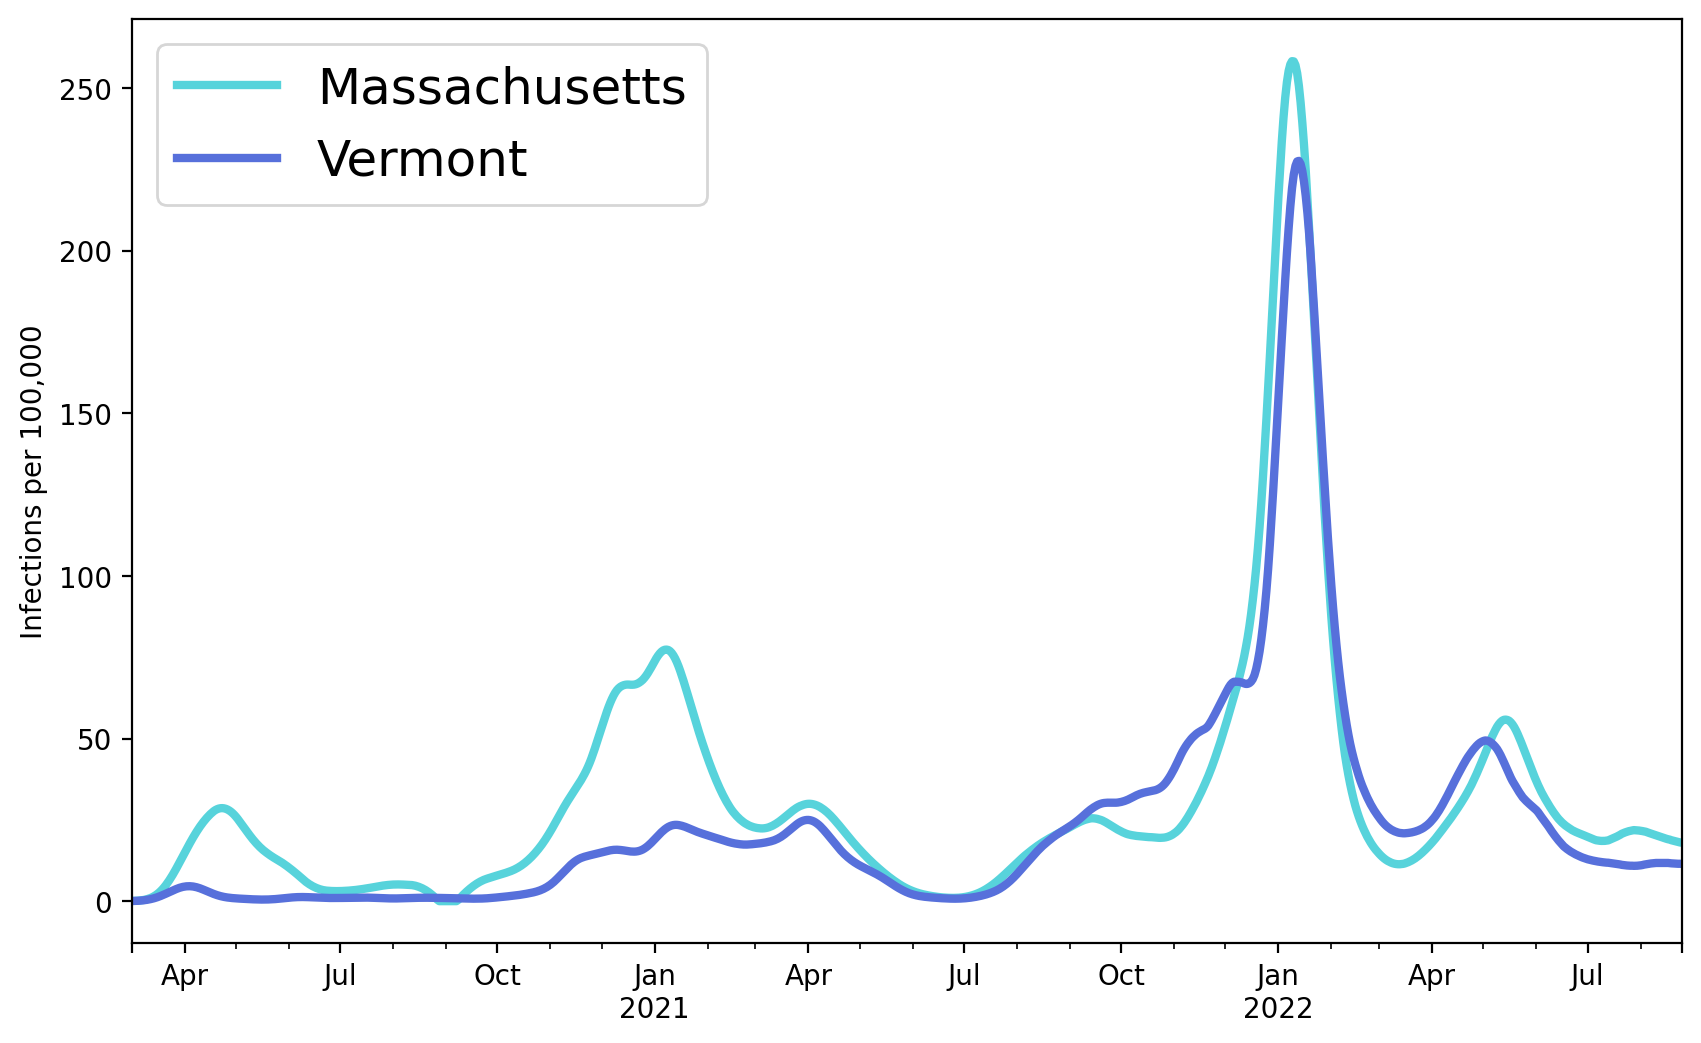

In [3]:
custom_palette = sns.color_palette("hls",8)[4:]
fix,ax = plt.subplots(dpi=200, figsize = (10,6))
plt.rcParams.update({'font.size':18})
sns.color_palette("hls", 8)
locations = ['US_MA', 'US_VT']
infections.loc[:,locations].plot(ax=ax, color = custom_palette, linewidth = 3)
#sns.lineplot(data, x = data.index, y = locations[0], palette = 'hls')
#sns.lineplot(data, x = data.index, y = locations[1], palette = 'hls')
ax.set_ylabel('Infections per 100,000')
ax.set_xlabel('')
plt.legend(['Massachusetts', 'Vermont'])

### Map visualization

In [4]:
# Shape file with geographic info for each state -- required for graphing
state_map = gpd.read_file("../data/state/visualization/tl_rd22_us_state.shp")
drops = ['Hawaii', 'Alaska', 'Puerto Rico', 'United States Virgin Islands', 'Commonwealth of the Northern Mariana Islands', 'Guam', 'American Samoa'] 
state_map = state_map.drop(state_map.loc[state_map.NAME.isin(drops)].index, axis = 0)
state_map.index = range(len(state_map))

translator = {'US_AK': 'Alaska', 'US_AL':'Alabama', 'US_AR':'Arkansas', 'US_AZ':'Arizona', 'US_CA':'California',
             'US_CO':'Colorado', 'US_CT':'Connecticut', 'US_DC':'District of Columbia', 'US_DE':'Delaware', 
             'US_FL':'Florida', 'US_GA':'Georgia', 'US_HI':'Hawaii', 'US_IA': 'Iowa', 'US_ID':'Idaho',
             'US_IL':'Illinois', 'US_IN':'Indiana', 'US_KS':'Kansas', 'US_KY':'Kentucky', 'US_LA':'Louisiana',
             'US_MA':'Massachusetts', 'US_MD':'Maryland', 'US_ME':'Maine', 'US_MI':'Michigan', 'US_MN':'Minnesota',
             'US_MO':'Missouri', 'US_MS':'Mississippi', 'US_MT':'Montana', 'US_NC':'North Carolina', 'US_ND':'North Dakota',
             'US_NE':'Nebraska', 'US_NH':'New Hampshire', 'US_NJ':'New Jersey', 'US_NM':'New Mexico', 'US_NV':'Nevada',
             'US_NY':'New York', 'US_OH':'Ohio', 'US_OK':'Oklahoma', 'US_OR':'Oregon', 'US_PA':'Pennsylvania', 
             'US_PR':'Puerto Rico', 'US_RI':'Rhode Island', 'US_SC':'South Carolina', 'US_SD':'South Dakota',
             'US_TN':'Tennessee', 'US_TX':'Texas', 'US_UT':'Utah', 'US_VA':'Virginia', 'US_VT':'Vermont', 'US_WA':'Washington',
             'US_WI':'Wisconsin', 'US_WV':'West Virginia', 'US_WY':'Wyoming'}

data_locations = [translator[_] for _ in infections.columns]

(20.0, 52.0)

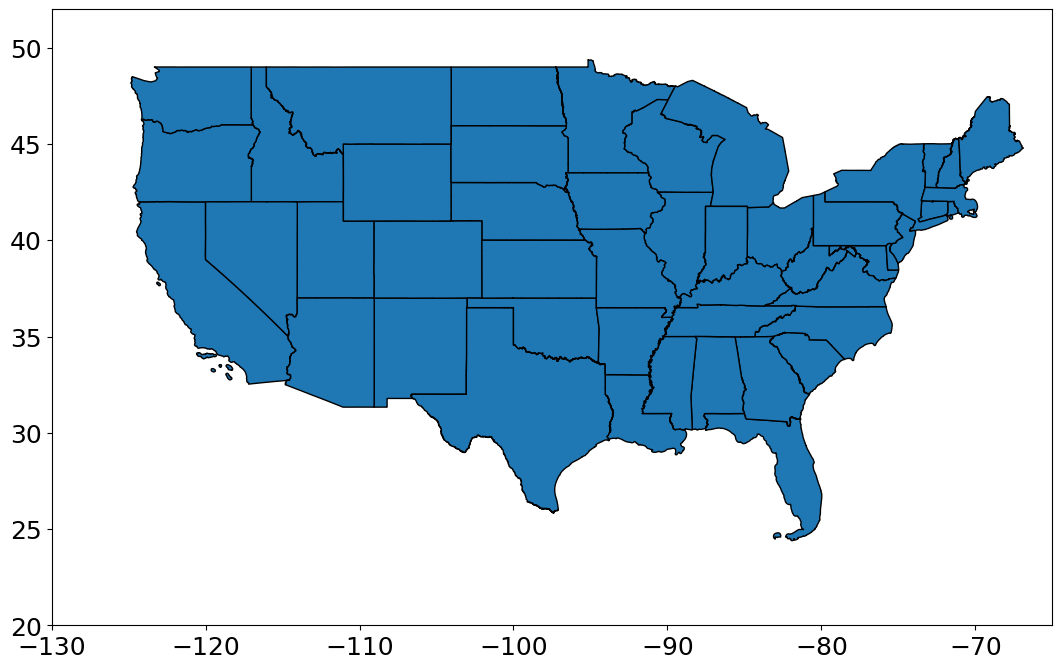

In [5]:
fig,ax = plt.subplots(figsize = (14,8))
state_map.plot(ax = ax, edgecolor="black")
ax.set_xlim(-130, -65)
ax.set_ylim(20,52)

# Segmentation

In [6]:
from scipy.spatial import distance

In [12]:
x = np.abs(np.random.normal(size = 1000))
y = np.abs(np.random.normal(size = 1000))

start = time.time()
d = np.linalg.norm(x - y, ord = 2)
end = time.time()
print('linalg: ' + str(end - start))
print(d)

start = time.time()
d = np.sqrt(np.sum((x - y)**2))
end = time.time()
print('sqrt: ' + str(end - start))
print(d)

start = time.time()
d = distance.euclidean(x,y)
end = time.time()
print('scipy1: ' + str(end - start))
print(d)

start = time.time()
d = distance.cdist(x,y, 'euclidean')
end = time.time()
print('scipy2: ' + str(end - start))
print(d)

linalg: 7.104873657226562e-05
27.099055791790057
sqrt: 7.295608520507812e-05
27.099055791790057
scipy1: 9.989738464355469e-05
27.099055791790057


ValueError: XA must be a 2-dimensional array.

### Unimodal

In [19]:
# data vector to fit the model with
location = 'US_MA'
data_vec = infections.loc[:,location].to_numpy().flatten().astype(np.float64)

In [20]:
unifit = Unimodal(penalty_by_length = 15)
start = time.time()
unifit.fit(data_vec)
end = time.time()
print(end - start)
inflections = unifit.inflections
directions = unifit.directions
fit_vec = unifit.est
wave_inflections = unifit.waves

3.926900863647461


Text(0.5, 0, 'date')

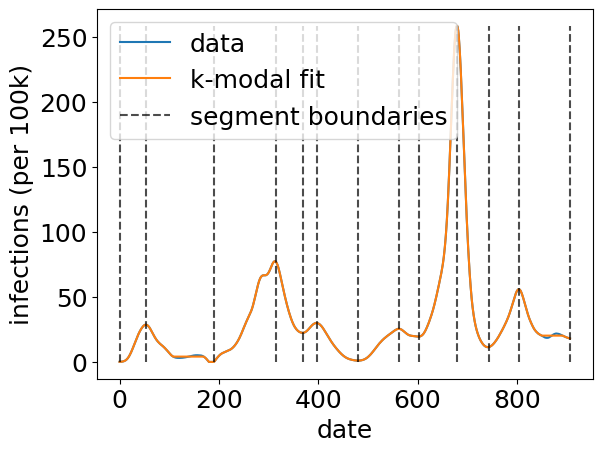

In [21]:
# and visualize the results!
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(inflections)):
    if i == 0:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

Text(0.5, 0, 'date')

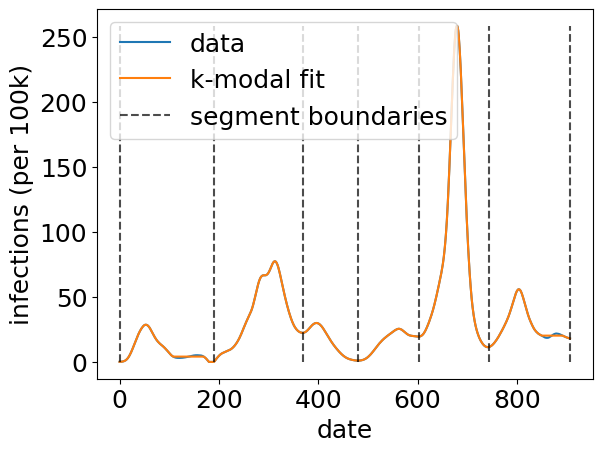

In [22]:
# Now showing the final result,
# which are the 'waves' instead of each isotonic piece.
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(wave_inflections)):
    if i == 0:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

# Dynamic Time Warp

Now that we have segments we'd like to be able to compare them. The problem is that these segments are varying in size and are usually offset in time. To avoid these issues we use dynamic time warping 

In [23]:
# first lets choose two segments to compare
#x = data.loc[:,'US_MA'][173:479].to_numpy()
#y = data.loc[:,'US_RI'][150:425].to_numpy()
x = infections.loc[:,'US_MA'].to_numpy()
y = infections.loc[:,'US_RI'].to_numpy()
x_masked = wave_mask(x, 173, 479)
y_masked = wave_mask(y, 173, 479)

# normalize them by the max of the larger 
norm = max(x_masked.max(), y_masked.max())

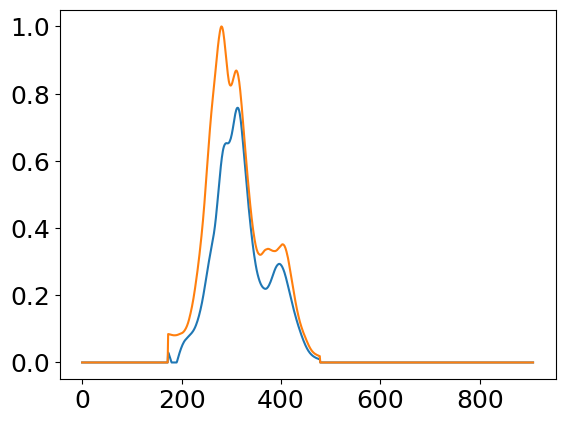

In [24]:
plt.plot(x_masked / norm)
plt.plot(y_masked / norm)

In [25]:
import time
DTW = DynamicTimeWarp(
    mult_penalty = np.array([1.0,1.0,1.0], dtype = np.float64),
    add_penalty = np.array([1/7,1/7,0.0], dtype = np.float64),
    normalize = True
)
start = time.time()
dist = DTW.fit(x_masked, y_masked)
end = time.time()
print(end - start)

Main loop time: 0.3982212543487549
Backtracking time: 0.0004940032958984375
0.3999481201171875


Text(0.5, 1.0, 'Alignment')

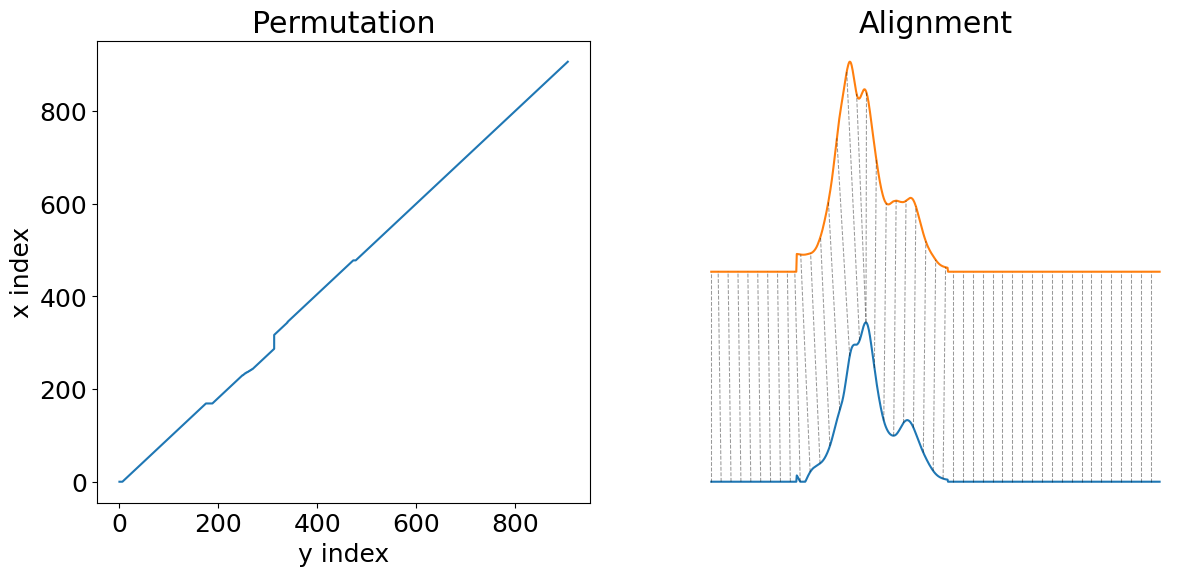

In [26]:
# and then plot the results
fig,ax = plt.subplots(1,2, figsize = (14,6), dpi = 100)
DTW.plot_permutation(axis = ax[0])
DTW.plot_alignment(x_masked / norm, y_masked / norm, offset = 1, skips = 20, axis = ax[1])
ax[0].set_ylabel('x index')
ax[0].set_xlabel('y index')
ax[1].axis('off')
ax[0].set_title('Permutation')
ax[1].set_title('Alignment')

### Wave Pool

In [42]:
n = 18_383_427
r = 371 / 10000
n * r * (1/60) * (1/60) * (1/24)

7.893809510416666

In [32]:
856/60

14.266666666666667

In [20]:
l = [1,2,3,4]

In [35]:
X = np.array([[1,2,3],[np.nan, np.nan, np.nan]])
Y = np.array([[np.nan, np.nan, np.nan], [4,5,6]])

In [41]:
np.nansum(X,  Y)

TypeError: only integer scalar arrays can be converted to a scalar index

In [30]:
wave_mod = Unimodal(penalty = 0.01, normalize = True)
dist_mod = DynamicTimeWarp(
    mult_penalty = np.array([1.0,1.0,1.0], dtype = np.float64),
    add_penalty = np.array([0.05,0.05,0.0], dtype = np.float64),
    normalize = True
)
wave_pool = WavePool(
    wave_module = wave_mod,
    distance_module = dist_mod,
    fit_waves_ = False,
    fit_distances_ = True,
    threshold = 0.5,
    mask = True,
    cpu_count = 2,
    distance_batch_size = 25
)

wave_pool.load_pool('../experiments/state/data/unimodal_pool.npz')
#wave_pool.load_distances('../experiments/state/data/unimodal_distances.npz')

import time
start = time.time()
wave_pool.fit(dataset)
end = time.time()

Parallel time: 198.84657907485962


In [48]:
pd.DataFrame(wave_pool.distances)

""


In [32]:
wave_pool.save_pool('../experiments/data/test_pool.npz')
wave_pool.save_distances('../experiments/data/test_distances.npz')

In [31]:
wave_pool.load_pool('../experiments/state/data/unimodal_pool.npz')
wave_pool.load_distances('../experiments/state/data/unimodal_distances.npz')

In [50]:
wave_pool.pool

In [34]:
pairs = [(1,2), (6,4), (3,2)]
for idx, (i,j) in enumerate(pairs):
    print(i)
    print(j)
    print()

1
2

6
4

3
2



In [37]:
pairs.pop(0)

(3, 2)

In [38]:
pairs

[]

In [40]:
(1000 * 0.4)/24

16.666666666666668

In [17]:
l1 = [1,2,3,4,5,6,7,8,9,10]
b = 4
l2 = [l1[i:i + b] for i in range(0,5,b)]

In [18]:
l2

[[1, 2, 3, 4], [5, 6, 7, 8]]

In [15]:
import itertools
list2d = [[1,2,3], [4,5,6], [7], [8,9]]
merged = list(itertools.chain.from_iterable(list2d))

In [16]:
merged

[1, 2, 3, 4, 5, 6, 7, 8, 9]

### Clustering

In [115]:
waves = WavePool()
waves.load_pool('../experiments/state/data/unimodal_pool.npz')
waves.load_distances('../experiments/state/data/unimodal_distances.npz')

pool = waves.pool
# Replace infs with large floats in distance matrix
D = waves.distances
D[D == np.inf] = np.finfo(D.dtype).max
wave_locations = [translator[infections.columns[_]] for _ in pool[:,0]]

In [131]:
clustering = AgglomerativeClustering(
    n_clusters = None,
    distance_threshold = np.finfo(D.dtype).max,
    compute_full_tree = True,
    metric = "precomputed",
    linkage = "complete"
).fit(D)

labels = clustering.labels_
k = len(np.unique(labels))

In [117]:
def wave_presence(data, pool):
    presence = np.zeros((data.shape[0], pool.shape[0]), dtype = bool)
    for i, (idx, start, stop) in enumerate(pool):
        presence[start:stop, i] = True
    return presence

def cluster_presence(data, pool, labels, threshold):
    clusters = np.unique(labels)
    k = len(clusters)
    wave_pres = wave_presence(data, pool)
    presence = np.zeros((data.shape[0], k), dtype = bool)
    presence_mean = np.full(presence.shape, np.nan, dtype = np.float64)
    presence_std = np.full(presence.shape, np.nan, dtype = np.float64)
    
    for i,c in enumerate(clusters):
        cwaves = np.where(labels == c)[0]
        cwaves_present = wave_pres[:,cwaves]
        cwave_fraction = np.sum(cwaves_present, axis = 1) / len(cwaves)
        present_times = np.where(cwave_fraction >= threshold)[0]
        presence[present_times, i] = True

        locations = pool[cwaves,0]
        subdata = data[present_times,:]
        subdata = subdata[:,locations]
        presence_mean[present_times, i] = np.nanmean(subdata, axis = 1)
        presence_std[present_times, i] = np.nanstd(subdata, axis = 1)

    return presence, presence_mean, presence_std

In [132]:
presence, presence_mean, presence_std = cluster_presence(dataset, pool, labels, 0.75)
start_time = [np.where(presence[:,i])[0][0] for i in range(k)]
ordered_start = np.argsort(start_time)

In [165]:
cmap = plt.get_cmap('tab20b')
cluster_colors = [cmap(i % 20 / 20) for i in range(k)]
cluster_cmap = colors.ListedColormap(
    ['white'] + cluster_colors
)
ordered_start_cluster_cmap = colors.ListedColormap(
    ['white'] + [cluster_colors[i] for i in ordered_start]
)

([], [])

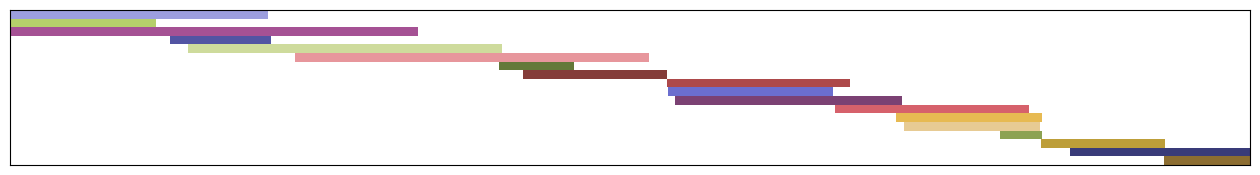

In [166]:
presence_val = presence * (clusters + 1)
plt.matshow(presence_val[:, ordered_start].T, aspect='auto', cmap=ordered_start_cluster_cmap)
plt.xticks([])
plt.yticks([]) 

In [195]:
'''
time = 1
timed_clusters = np.where(presence[time,:])[0]

sequential_cmap = plt.cm.tab20b
colors = [(1, 1, 1)] + [sequential_cmap(i) for i in range(20)]
custom_cmap = ListedColormap(colors)

color_indices = np.round(
    np.linspace(1, len(colors) - 1, len(timed_clusters))
).astype(int)
color_dict = {
    timed_clusters[i]:colors[color_indices[i]] for i in range(len(timed_clusters))
}
color_dict[-1] = colors[0]
'''

([], [])

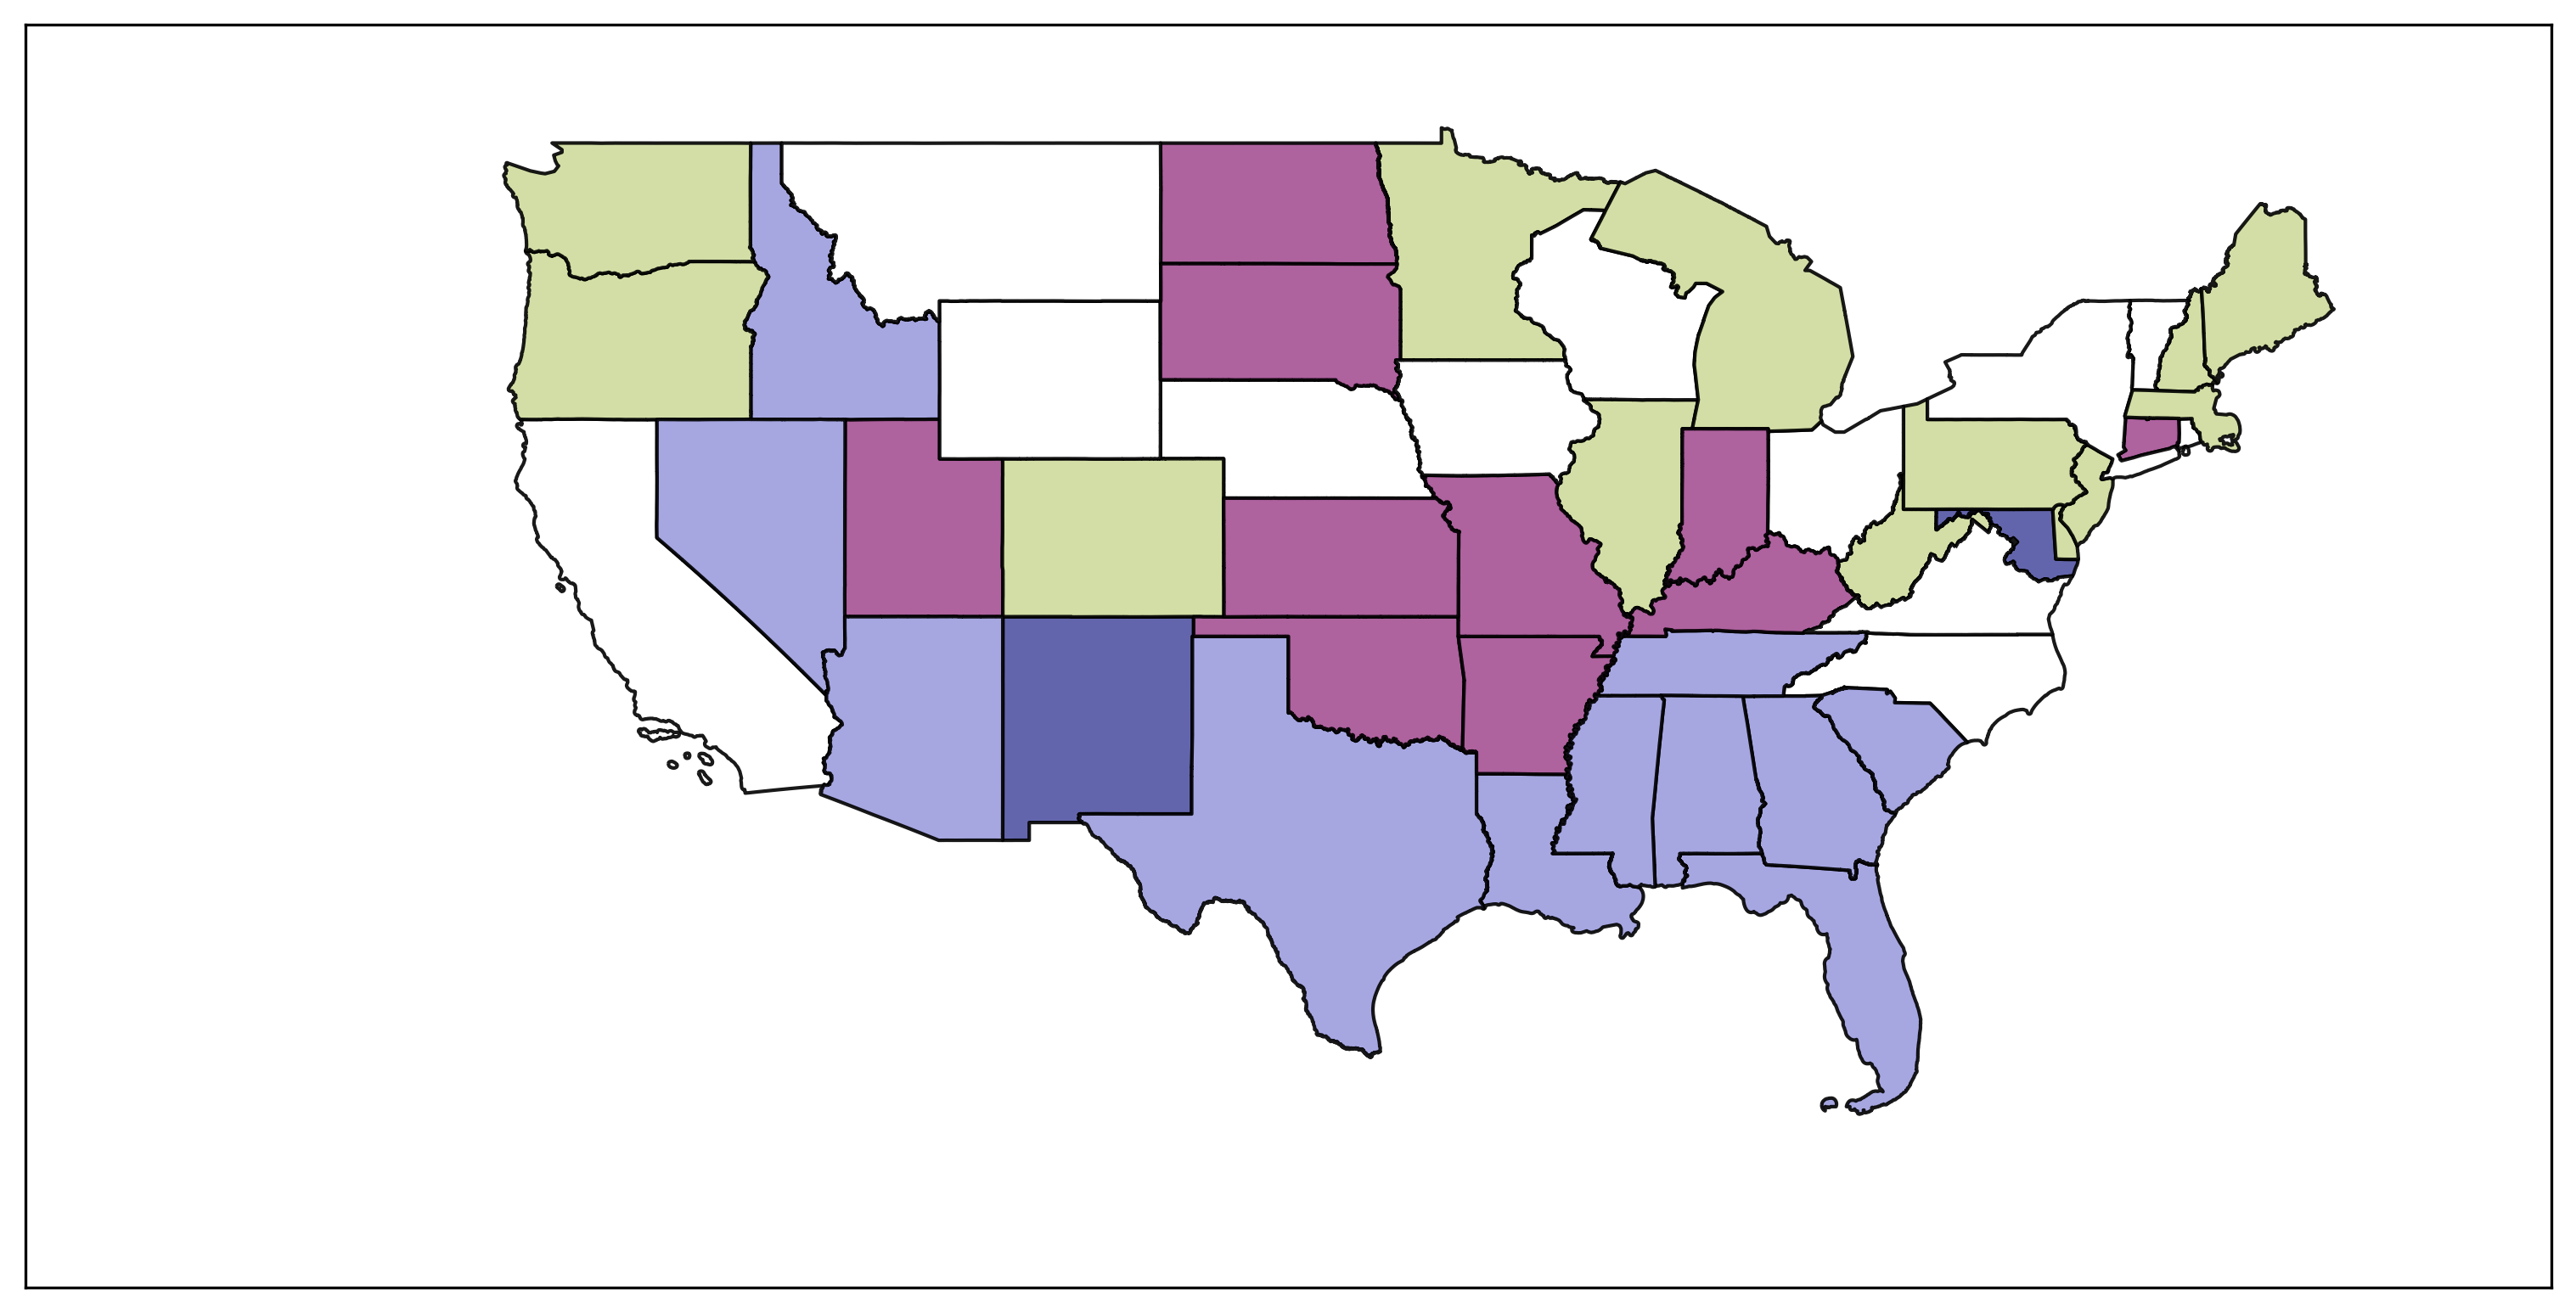

In [206]:
time = 150
timed_clusters = np.where(presence[time,:])[0]

color_vals = np.zeros(len(state_map))
for i in timed_clusters:
    clust = np.where(labels == i)[0]
    for j in clust:
        location = wave_locations[j]
        ind = state_map.loc[state_map.NAME == location].index[0]
        color_vals[ind] = i + 1

color_val = [ordered_start_cluster_cmap(int(i)) for i in color_vals]
state_map['color'] = color_val

fig,ax = plt.subplots(1,1, constrained_layout=True, figsize = (10,10), dpi = 300)
state_map.plot(color=state_map['color'], legend=False, ax = ax, edgecolor = 'black', alpha = 0.9)
ax.set_xlim(-140, -60)
ax.set_ylim(20,52)
plt.xticks([])
plt.yticks([]) 

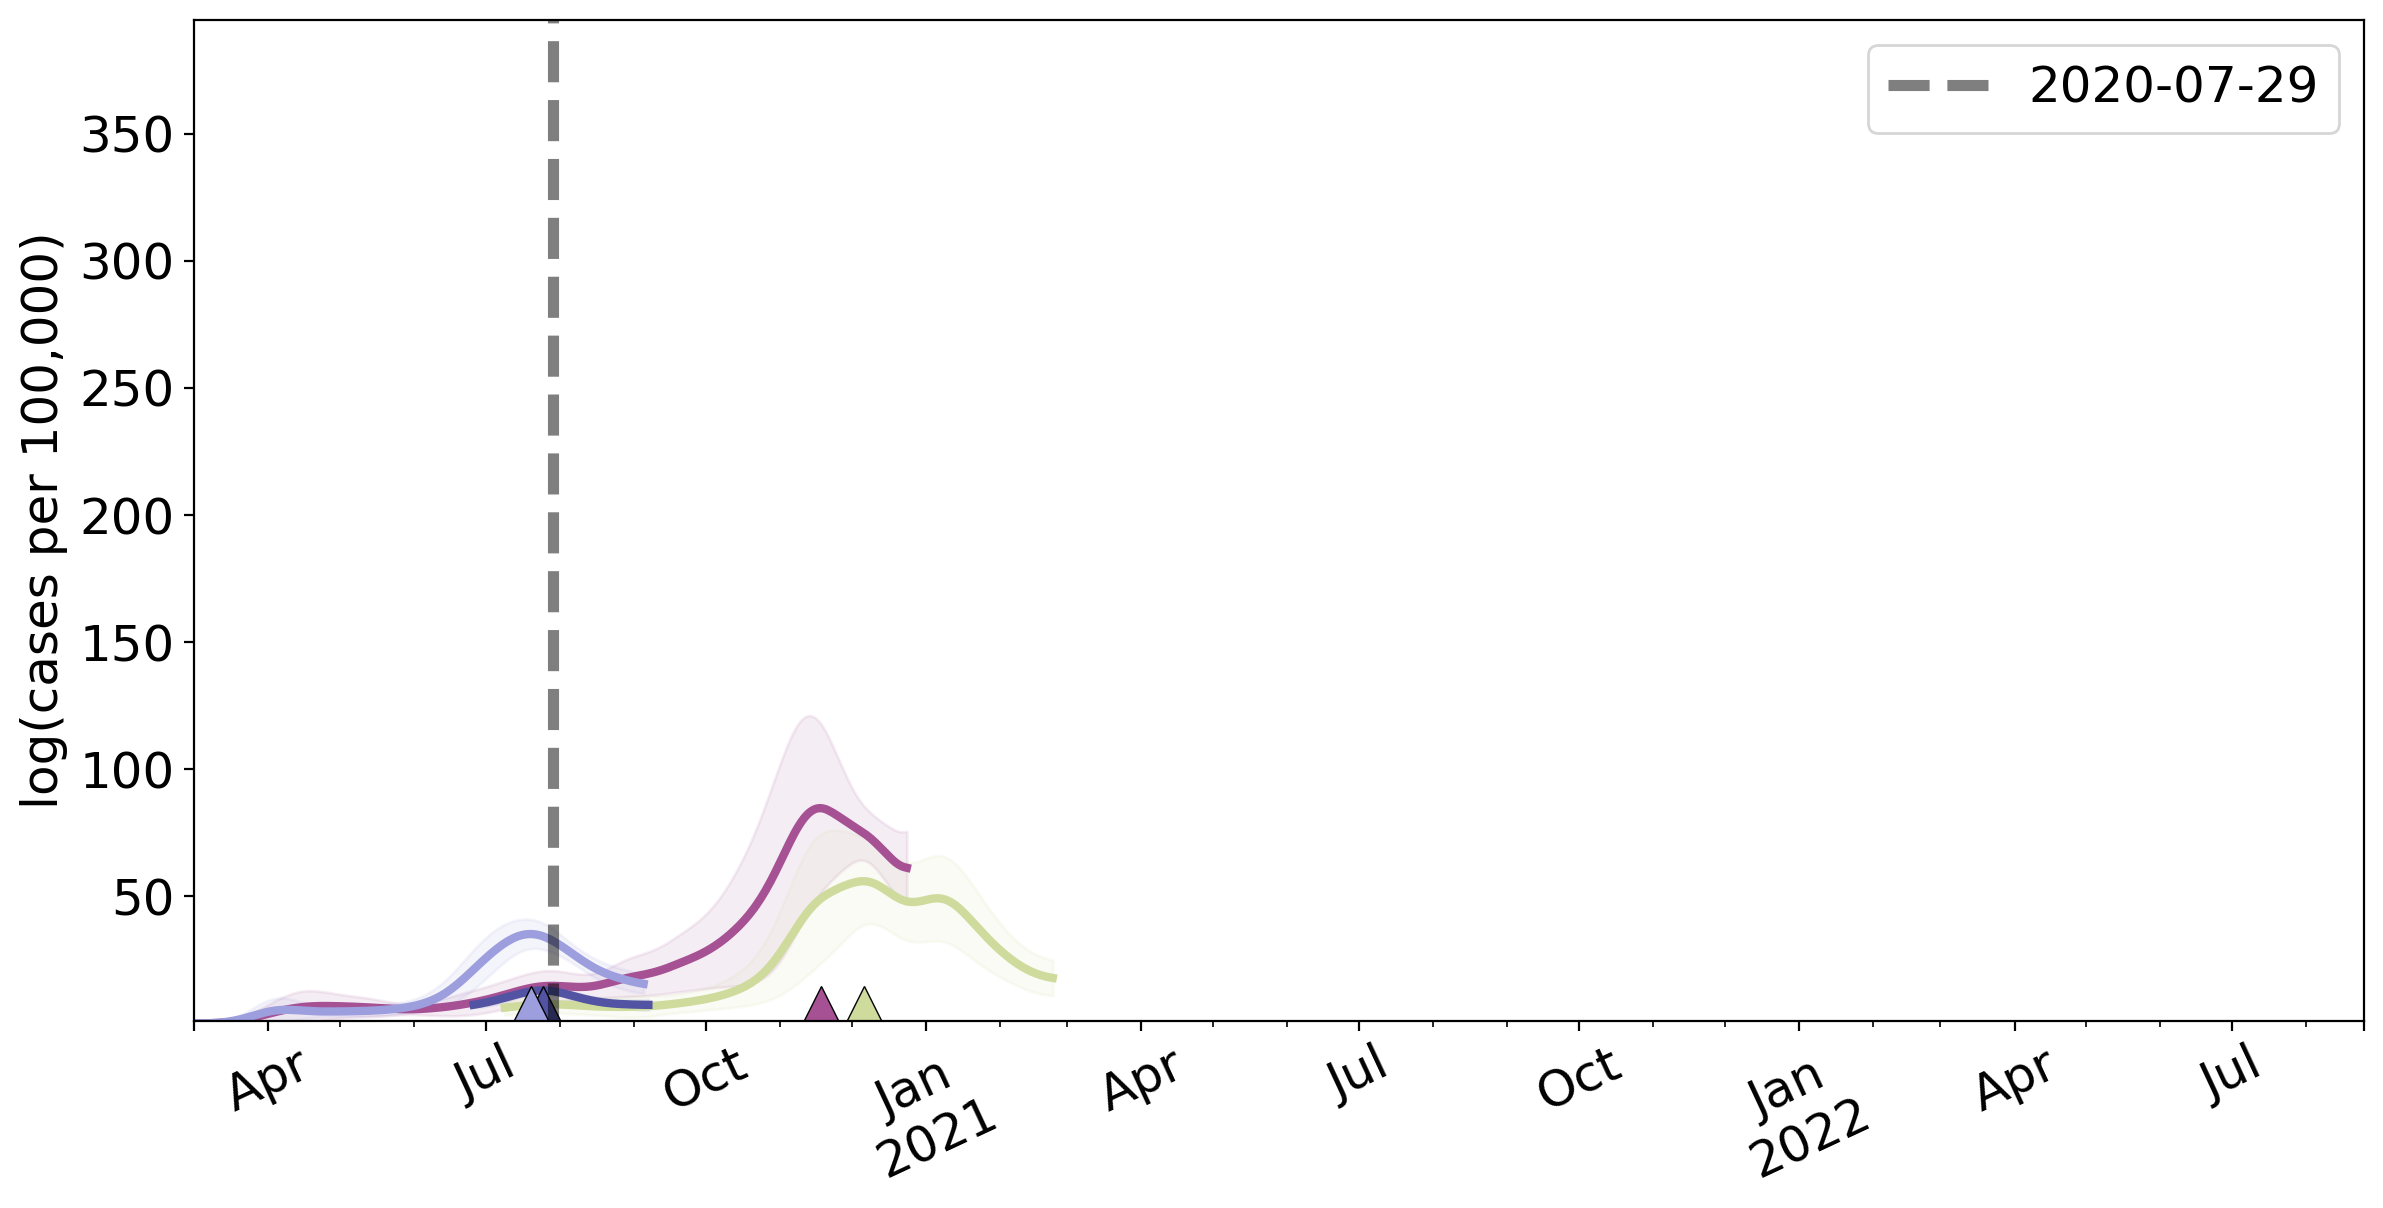

In [207]:
# For each of the clusters on the map,
# display the average wave associated with it
fig,ax = plt.subplots(figsize = (14,6.5), dpi = 200)
plt.rcParams.update({'font.size': 18})

# Dataframe allows for nicer plotting
indx = infections.index
mean_df = pd.DataFrame(presence_mean, index = indx)
std_df = pd.DataFrame(presence_std, index = indx)

for i in timed_clusters:
    #clust_color = color_dict[i]
    clust_color = ordered_start_cluster_cmap(i + 1)
    imean = mean_df.iloc[:,i]
    istd = std_df.iloc[:,i]
    max_idx = np.argmax(imean)
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore')
        imean.plot(c = clust_color, linewidth = 3, label='_no_legend_', ax = ax)
        ax.fill_between(indx, imean - istd, imean + istd, color=clust_color, alpha=0.1)
        ax.plot(indx[max_idx:max_idx + 1], 1, marker='^', markersize=25, c=clust_color, markeredgewidth=0.5, markeredgecolor='black')
    
data_max = infections.max().max()
date_line = ax.vlines(x = infections.index[time], ymin = 0, ymax = data_max, linestyle = '--', color = 'k', linewidth = 4, label = str(infections.index[time])[:10], alpha = 0.5)
ax.set_xlabel('')
ax.set_ylabel('log(cases per 100,000)')
#ax.set_yscale('log', base=10)
ax.set_ylim(1, data_max)
plt.xticks(rotation=25) 
plt.legend()